## **0. Download dataset**
**Note:** If you can't download using gdown due to limited number of downloads, please download it manually and upload it to your drive, then copy it from the drive to colab.
```python
from google.colab import drive

drive.mount('/content/drive')
!cp /path/to/dataset/on/your/drive .
```

In [ ]:
# https://drive.google.com/file/d/1KehLp3sWEtKtSARYoV7luPqDHtRPj10R/view?usp=drive_link
#!gdown 1KehLp3sWEtKtSARYoV7luPqDHtRPj10R
#!unzip titanic.zip

## **1. Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## **2. Read dataset**

In [2]:
dataset_path = '../Data/titanic_modified_dataset.csv'
df = pd.read_csv(
    dataset_path,
    index_col='PassengerId'
)
df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Survived
PassengerId,,,,,,,,,
1,3,0,22.0,1,0,7.2500,0,0,0
2,1,1,38.0,1,0,71.2833,1,1,1
3,3,1,26.0,0,0,7.9250,0,2,1
4,1,1,35.0,1,0,53.1000,0,1,1
5,3,0,35.0,0,0,8.0500,0,0,0
...,...,...,...,...,...,...,...,...,...
887,2,0,27.0,0,0,13.0000,0,5,0
888,1,1,19.0,0,0,30.0000,0,2,1
889,3,1,28.0,1,2,23.4500,0,2,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    int64  
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  891 non-null    int64  
 7   Title     891 non-null    int64  
 8   Survived  891 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 62.8 KB


In [4]:
df.describe()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Survived
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,2.308642,0.352413,29.361582,0.523008,0.381594,32.204208,0.359147,0.936027,0.383838
std,0.836071,0.477990,13.019697,1.102743,0.806057,49.693429,0.638707,1.725341,0.486592
min,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000
25%,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400,0.000000,0.000000,0.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,0.000000,0.000000,0.000000
75%,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000,1.000000,2.000000,1.000000
max,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,2.000000,16.000000,1.000000


## **3. Create train, val, test set**

In [5]:
dataset_arr = df.to_numpy().astype(np.float64)
X, y = dataset_arr[:, :-1], dataset_arr[:, -1]

In [6]:
print(X.shape)

(891, 8)


In [7]:
intercept = np.ones((
    X.shape[0], 1)
)
X_b = np.concatenate(
    (intercept, X),
    axis=1
)

In [8]:
print(X_b.shape)

(891, 9)


In [9]:
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    X_b, y,
    test_size=val_size,
    random_state=random_state,
    shuffle=is_shuffle
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size=test_size,
    random_state=random_state,
    shuffle=is_shuffle
)

In [10]:
print(f'Number of training samples: {X_train.shape[0]}')
print(f'Number of val samples: {X_val.shape[0]}')
print(f'Number of test samples: {X_test.shape[0]}')

Number of training samples: 623
Number of val samples: 179
Number of test samples: 89


## **4. Normalization**

In [11]:
normalizer = StandardScaler()
X_train[:, 1:] = normalizer.fit_transform(X_train[:, 1:])
X_val[:, 1:] = normalizer.transform(X_val[:, 1:])
X_test[:, 1:] = normalizer.transform(X_test[:, 1:])

In [12]:
X_train

array([[ 1.        ,  0.8380325 , -0.73366996, ..., -0.34812766,
         0.89679528, -0.55130115],
       [ 1.        , -1.55141486, -0.73366996, ...,  1.76556546,
        -0.60106922, -0.55130115],
       [ 1.        ,  0.8380325 , -0.73366996, ..., -0.47988477,
        -0.60106922, -0.55130115],
       ...,
       [ 1.        ,  0.8380325 , -0.73366996, ..., -0.48238806,
         2.39465977, -0.55130115],
       [ 1.        ,  0.8380325 , -0.73366996, ..., -0.22655193,
        -0.60106922, -0.55130115],
       [ 1.        ,  0.8380325 , -0.73366996, ..., -0.05432564,
         2.39465977,  1.3289577 ]], shape=(623, 9))

## **5. Define essential functions**

### **5.1. Sigmoid function**

In [13]:
def sigmoid(z):
    #***Your code here***
    return np.exp(z) / (1 + np.exp(z))

### **5.2. Hypothesis function**

In [14]:
def predict(X, theta):
    dot_product = np.dot(X, theta) #***Your code here***
    y_hat = sigmoid(dot_product) #***Your code here***

    return y_hat

### **5.3. Binary Cross-entropy loss function**

In [24]:
def compute_loss(y_hat, y):
    y_hat = np.clip(
        y_hat, 1e-7, 1 - 1e-7
    )

    return - 1/len(y) * np.sum(y*np.log(y_hat) + (1 - y)*np.log(1 - y_hat)) #***Your code here***

### **5.4. Gradient function**

In [22]:
def compute_gradient(X, y, y_hat):
    return 1/len(X) * (X.T @ (y_hat - y)) #***Your code here***

### **5.5. Update weights function**

In [17]:
def update_theta(theta, gradient, lr):
    return theta - lr*gradient #***Your code here***

### **5.6. Accuracy function**

In [18]:
def compute_accuracy(X, y, theta):
    y_hat = np.where(sigmoid(X @ theta) >= 0.5, 1, 0) #***Your code here***
    acc = np.mean(y_hat == y) #***Your code here***

    return acc

## **6. Training**

In [19]:
lr = 0.01
epochs = 100
batch_size = 16

np.random.seed(random_state)
theta = np.random.uniform(
    size=X_train.shape[1]
)

In [25]:
train_accs = []
train_losses = []
val_accs = []
val_losses = []

for epoch in range(epochs):
    train_batch_losses = []
    train_batch_accs = []
    val_batch_losses = []
    val_batch_accs = []

    for i in range(0, X_train.shape[0], batch_size):
        X_i = X_train[i:i+batch_size]
        y_i = y_train[i:i+batch_size]

        y_hat = predict(X_i, theta) #***Your code here***

        train_loss = compute_loss(y_hat, y_i) #***Your code here***

        gradient = compute_gradient(X_i, y_i, y_hat) #***Your code here***

        theta = update_theta(theta, gradient, lr) #***Your code here***

        train_batch_losses.append(train_loss)

        train_acc = compute_accuracy(X_train, y_train, theta)
        train_batch_accs.append(train_acc)

        y_val_hat = predict(X_val, theta)
        val_loss = compute_loss(y_val_hat, y_val)
        val_batch_losses.append(val_loss)

        val_acc = compute_accuracy(X_val, y_val, theta)
        val_batch_accs.append(val_acc)

    train_batch_loss = sum(train_batch_losses) / len(train_batch_losses)
    val_batch_loss = sum(val_batch_losses) / len(val_batch_losses)
    train_batch_acc = sum(train_batch_accs) / len(train_batch_accs)
    val_batch_acc = sum(val_batch_accs) / len(val_batch_accs)

    train_losses.append(train_batch_loss)
    val_losses.append(val_batch_loss)
    train_accs.append(train_batch_acc)
    val_accs.append(val_batch_acc)

    print(f'\nEPOCH {epoch + 1}:\tTraining loss: {train_batch_loss:.3f}\tValidation loss: {val_batch_loss:.3f}')


EPOCH 1:	Training loss: 0.412	Validation loss: 0.519

EPOCH 2:	Training loss: 0.412	Validation loss: 0.519

EPOCH 3:	Training loss: 0.412	Validation loss: 0.520

EPOCH 4:	Training loss: 0.412	Validation loss: 0.520

EPOCH 5:	Training loss: 0.412	Validation loss: 0.520

EPOCH 6:	Training loss: 0.412	Validation loss: 0.520

EPOCH 7:	Training loss: 0.412	Validation loss: 0.520

EPOCH 8:	Training loss: 0.412	Validation loss: 0.520

EPOCH 9:	Training loss: 0.412	Validation loss: 0.520

EPOCH 10:	Training loss: 0.412	Validation loss: 0.520

EPOCH 11:	Training loss: 0.412	Validation loss: 0.520

EPOCH 12:	Training loss: 0.412	Validation loss: 0.520

EPOCH 13:	Training loss: 0.412	Validation loss: 0.520

EPOCH 14:	Training loss: 0.412	Validation loss: 0.521

EPOCH 15:	Training loss: 0.412	Validation loss: 0.521

EPOCH 16:	Training loss: 0.412	Validation loss: 0.521

EPOCH 17:	Training loss: 0.412	Validation loss: 0.521

EPOCH 18:	Training loss: 0.412	Validation loss: 0.521

EPOCH 19:	Training

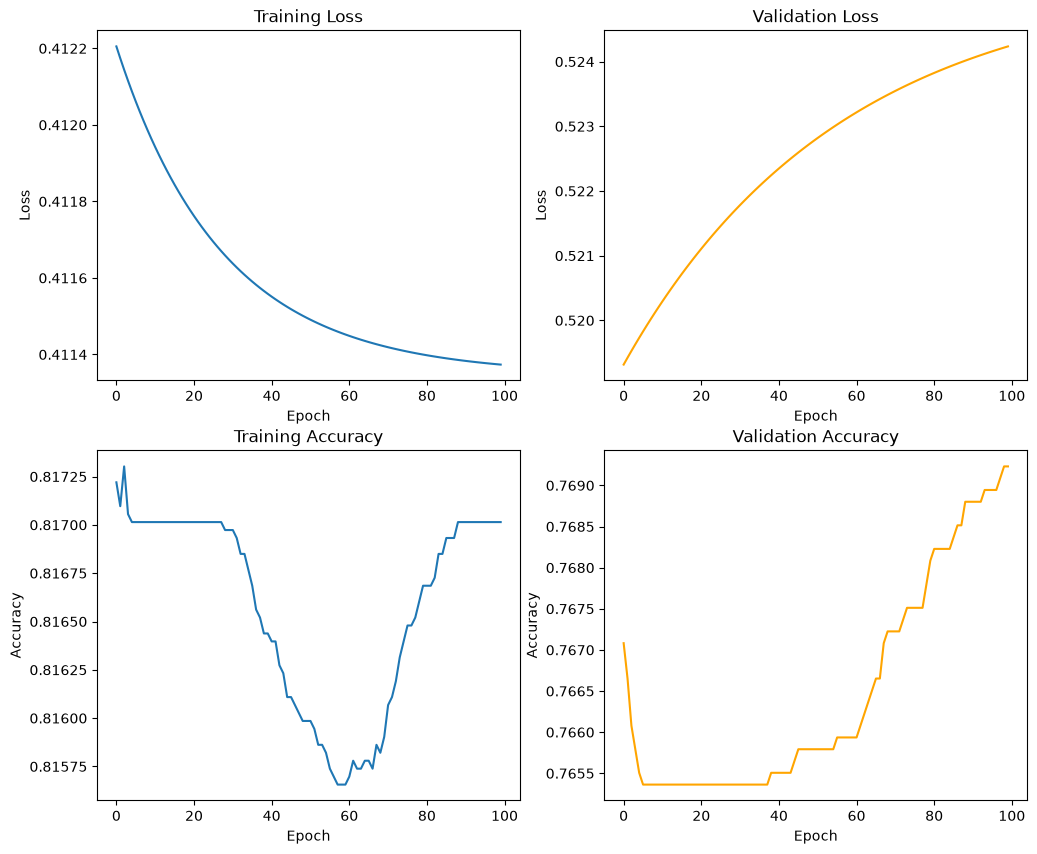

In [26]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0, 0].plot(train_losses)
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot(val_losses, 'orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot(train_accs)
ax[1, 0].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 0].set_title('Training Accuracy')

ax[1, 1].plot(val_accs, 'orange')
ax[1, 1].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.show()

## **7. Evaluation**

In [27]:
# Val set
val_set_acc = compute_accuracy(X_val, y_val, theta)
print('Evaluation on validation set:')
print(f'Accuracy: {val_set_acc}')

Evaluation on validation set:
Accuracy: 0.770949720670391


In [28]:
# Test set
test_set_acc = compute_accuracy(X_test, y_test, theta)
print('Evaluation on test set:')
print(f'Accuracy: {test_set_acc}')

Evaluation on test set:
Accuracy: 0.7865168539325843
